<a href="https://colab.research.google.com/github/sk-imran-dev/CodeOrbit-Task2/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TASK 2: SALES DATA ANALYSIS USING PYTHON AND PANDAS

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload dataset
from google.colab import files

uploaded = files.upload()

Saving Task_2_Sales_Data_500_Rows.csv to Task_2_Sales_Data_500_Rows.csv


In [ ]:
# Load the dataset

df = pd.read_csv("Task_2_Sales_Data_500_Rows.csv")

print("Dataset loaded successfully!")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset loaded successfully!
Number of Rows: 500
Number of Columns: 8


In [ ]:
print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== FIRST 5 ROWS =====")
display(df.head())

print("\n===== LAST 5 ROWS =====")
display(df.tail())

print("\n===== DATASET INFORMATION =====")
df.info()


===== COLUMN NAMES =====
['Order_ID', 'Date', 'Product', 'Category', 'Region', 'Quantity', 'Unit_Price', 'Sales']

===== FIRST 5 ROWS =====


,Order_ID,Date,Product,Category,Region,Quantity,Unit_Price,Sales
0,1001,09-01-2026,Laptop,Electronics,East,5,32380.89,161904.45
1,1002,17-09-2026,Laptop,Electronics,East,8,12498.57,99988.56
2,1003,13-06-2026,Laptop,Electronics,East,10,52676.84,526768.40
3,1004,25-05-2026,Laptop,Electronics,North,10,52159.43,521594.30
4,1005,21-08-2026,Laptop,Electronics,North,4,126215.04,504860.16



===== LAST 5 ROWS =====


,Order_ID,Date,Product,Category,Region,Quantity,Unit_Price,Sales
495,1496,13-05-2026,Mouse,Accessories,East,5,897.33,4486.65
496,1497,17-08-2026,Mouse,Accessories,South,6,896.16,5376.96
497,1498,17-05-2026,Mouse,Accessories,West,7,340.98,2386.86
498,1499,13-07-2026,Mouse,Accessories,North,4,880.27,3521.08
499,1500,05-02-2026,Mouse,Accessories,South,7,1340.86,9386.02



===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    500 non-null    int64  
 1   Date        500 non-null    object 
 2   Product     500 non-null    object 
 3   Category    500 non-null    object 
 4   Region      500 non-null    object 
 5   Quantity    500 non-null    int64  
 6   Unit_Price  500 non-null    float64
 7   Sales       500 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 31.4+ KB


In [ ]:
# Check missing values

print("===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print("Number of Duplicate Rows:", df.duplicated().sum())

# Convert Date column to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

print("\n===== DATE COLUMN DATA TYPE =====")
print(df["Date"].dtype)

===== MISSING VALUES =====
Order_ID      0
Date          0
Product       0
Category      0
Region        0
Quantity      0
Unit_Price    0
Sales         0
dtype: int64

===== DUPLICATE ROWS =====
Number of Duplicate Rows: 0

===== DATE COLUMN DATA TYPE =====
datetime64[ns]


In [ ]:
# Calculate sales independently

df["Calculated_Sales"] = (
    df["Quantity"] * df["Unit_Price"]
).round(2)

# Compare calculated sales with existing Sales column

df["Sales_Check"] = np.isclose(
    df["Sales"],
    df["Calculated_Sales"],
    atol=0.01
)

print("===== SALES CALCULATION VERIFICATION =====")

print(
    "All sales values are correct:",
    df["Sales_Check"].all()
)

print("\n===== SAMPLE SALES CALCULATION =====")

display(
    df[
        [
            "Product",
            "Quantity",
            "Unit_Price",
            "Sales",
            "Calculated_Sales"
        ]
    ].head()
)

===== SALES CALCULATION VERIFICATION =====
All sales values are correct: True

===== SAMPLE SALES CALCULATION =====


,Product,Quantity,Unit_Price,Sales,Calculated_Sales
0,Laptop,5,32380.89,161904.45,161904.45
1,Laptop,8,12498.57,99988.56,99988.56
2,Laptop,10,52676.84,526768.40,526768.40
3,Laptop,10,52159.43,521594.30,521594.30
4,Laptop,4,126215.04,504860.16,504860.16


In [ ]:
# Total Sales

total_sales = df["Sales"].sum()

# Total number of orders

total_orders = df["Order_ID"].nunique()

# Average Order Value

average_order_value = (
    total_sales / total_orders
)

print("===== KEY SALES METRICS =====")
print("-" * 35)

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(
    f"Average Order Value: ₹{average_order_value:,.2f}"
)

===== KEY SALES METRICS =====
-----------------------------------
Total Sales: ₹45,554,764.33
Total Orders: 500
Average Order Value: ₹91,109.53


In [ ]:
# Product-wise sales summary

product_summary = df.groupby("Product").agg(
    Total_Sales=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Orders=("Order_ID", "nunique")
).sort_values(
    by="Total_Sales",
    ascending=False
)

print("===== PRODUCT-WISE SALES SUMMARY =====")

display(product_summary)

===== PRODUCT-WISE SALES SUMMARY =====


,Total_Sales,Total_Quantity,Number_of_Orders
Product,,,
Laptop,20169801.80,367,62
Smartphone,8862771.70,278,54
Tablet,5575348.09,199,44
Desk,2918696.79,265,51
Monitor,2407479.57,200,41
Office Chair,2368827.04,318,55
Printer,1958942.58,208,39
Headphones,594728.72,270,49
Keyboard,482308.39,322,57


In [ ]:
# Top 5 products

top_products = product_summary.head(5)

print("===== TOP 5 PRODUCTS BY SALES =====")

display(top_products)

===== TOP 5 PRODUCTS BY SALES =====


,Total_Sales,Total_Quantity,Number_of_Orders
Product,,,
Laptop,20169801.80,367,62
Smartphone,8862771.70,278,54
Tablet,5575348.09,199,44
Desk,2918696.79,265,51
Monitor,2407479.57,200,41


In [ ]:
# Category analysis

category_summary = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Orders=("Order_ID", "nunique")
).sort_values(
    by="Total_Sales",
    ascending=False
)

print("===== SALES BY CATEGORY =====")

display(category_summary)

===== SALES BY CATEGORY =====


,Total_Sales,Total_Quantity,Number_of_Orders
Category,,,
Electronics,37015401.16,1044,201
Furniture,5287523.83,583,106
Office Equipment,1958942.58,208,39
Accessories,1292896.76,862,154


In [ ]:
# Region analysis

region_summary = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Orders=("Order_ID", "nunique")
).sort_values(
    by="Total_Sales",
    ascending=False
)

print("===== SALES BY REGION =====")

display(region_summary)

===== SALES BY REGION =====


,Total_Sales,Total_Quantity,Number_of_Orders
Region,,,
South,13752338.12,722,128
West,10963240.56,656,121
North,10896520.25,679,124
East,9942665.40,640,127


In [ ]:
# Create Month column

df["Month"] = (
    df["Date"]
    .dt.to_period("M")
    .astype(str)
)

# Monthly sales

monthly_sales = df.groupby("Month").agg(
    Total_Sales=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Orders=("Order_ID", "nunique")
)

print("===== MONTHLY SALES SUMMARY =====")

display(monthly_sales)

===== MONTHLY SALES SUMMARY =====


,Total_Sales,Total_Quantity,Number_of_Orders
Month,,,
2026-01,4264743.45,294,57
2026-02,5310519.40,278,53
2026-03,3810419.08,220,44
2026-04,6684316.02,272,53
2026-05,5597945.99,287,51
2026-06,5619118.05,277,49
2026-07,4220625.10,324,57
2026-08,6181159.27,312,60
2026-09,3865917.97,433,76


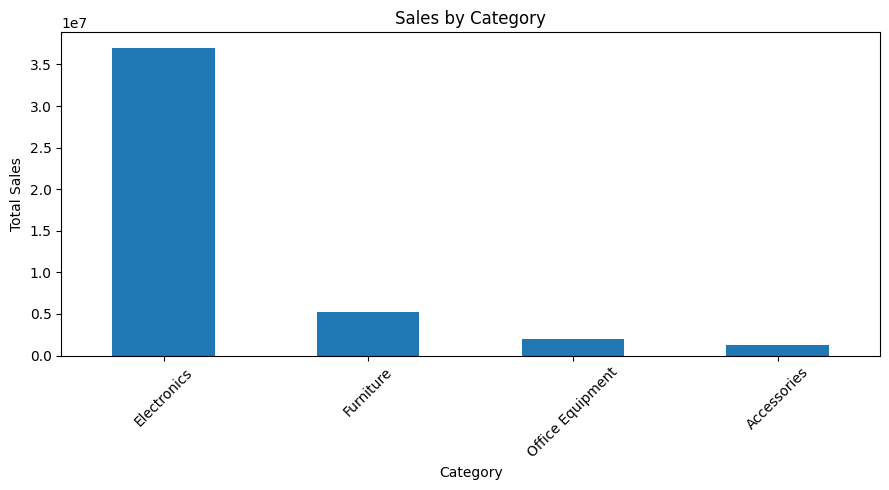

In [ ]:
# Category Sales Chart

plt.figure(figsize=(9, 5))

category_summary["Total_Sales"].plot(
    kind="bar"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

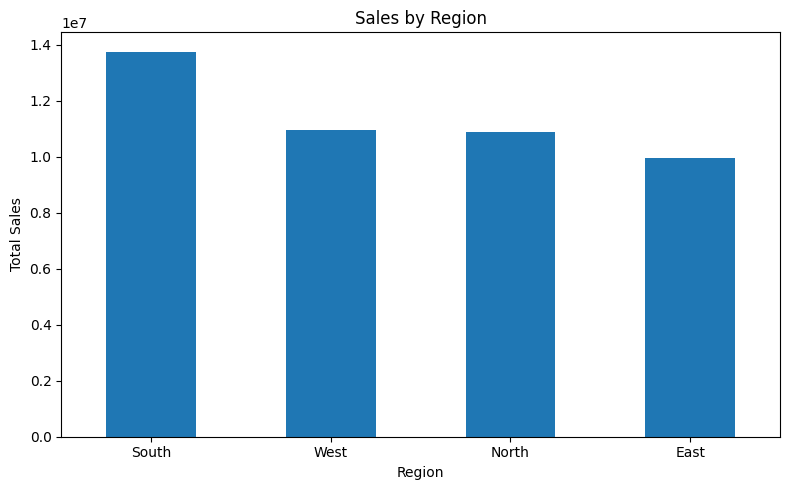

In [ ]:
# Region Sales Chart

plt.figure(figsize=(8, 5))

region_summary["Total_Sales"].plot(
    kind="bar"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

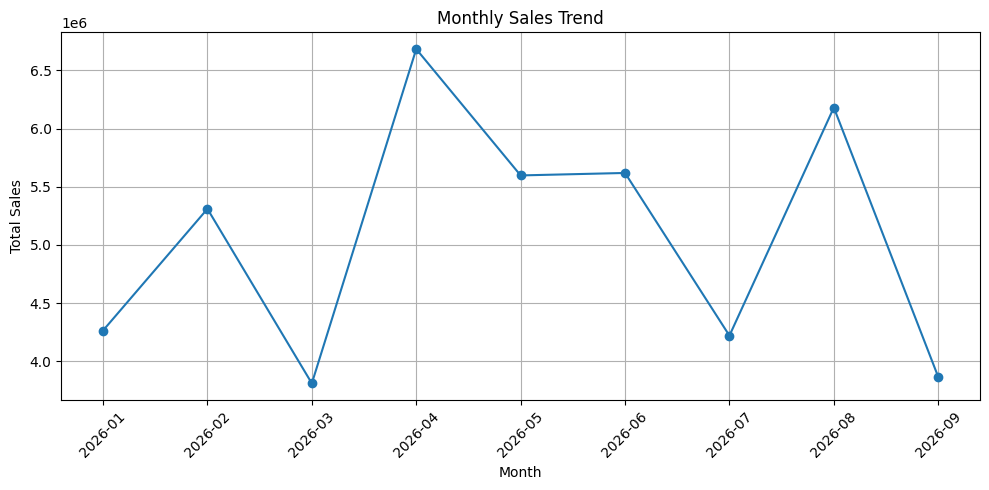

In [ ]:
# Monthly Sales Chart

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Identify highest-performing items

top_product = product_summary.index[0]
top_product_sales = product_summary.iloc[0]["Total_Sales"]

top_category = category_summary.index[0]
top_category_sales = category_summary.iloc[0]["Total_Sales"]

top_region = region_summary.index[0]
top_region_sales = region_summary.iloc[0]["Total_Sales"]

top_month = monthly_sales["Total_Sales"].idxmax()
top_month_sales = monthly_sales["Total_Sales"].max()


print("===== KEY FINDINGS =====")
print("=" * 45)

print(
    f"1. Total Sales: ₹{total_sales:,.2f}"
)

print(
    f"2. Average Order Value: ₹{average_order_value:,.2f}"
)

print(
    f"3. Top Product: {top_product} "
    f"(₹{top_product_sales:,.2f})"
)

print(
    f"4. Top Category: {top_category} "
    f"(₹{top_category_sales:,.2f})"
)

print(
    f"5. Top Region: {top_region} "
    f"(₹{top_region_sales:,.2f})"
)

print(
    f"6. Highest Sales Month: {top_month} "
    f"(₹{top_month_sales:,.2f})"
)

===== KEY FINDINGS =====
1. Total Sales: ₹45,554,764.33
2. Average Order Value: ₹91,109.53
3. Top Product: Laptop (₹20,169,801.80)
4. Top Category: Electronics (₹37,015,401.16)
5. Top Region: South (₹13,752,338.12)
6. Highest Sales Month: 2026-04 (₹6,684,316.02)


In [ ]:
# Final summary table

summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Sales",
        "Average Order Value",
        "Top Product",
        "Top Category",
        "Top Region",
        "Best Sales Month"
    ],

    "Value": [
        total_orders,
        f"₹{total_sales:,.2f}",
        f"₹{average_order_value:,.2f}",
        top_product,
        top_category,
        top_region,
        top_month
    ]
})

display(summary)

,Metric,Value
0,Total Orders,500
1,Total Sales,"₹45,554,764.33"
2,Average Order Value,"₹91,109.53"
3,Top Product,Laptop
4,Top Category,Electronics
5,Top Region,South
6,Best Sales Month,2026-04


In [ ]:
# Remove temporary verification columns

df = df.drop(
    columns=["Calculated_Sales", "Sales_Check"],
    errors="ignore"
)

# Save analyzed dataset

analyzed_file = "Imran_Farhath_Shaik_Task2_Analyzed_Dataset.csv"

df.to_csv(
    analyzed_file,
    index=False
)

print("Analyzed dataset saved successfully!")
print("File name:", analyzed_file)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Analyzed dataset saved successfully!
File name: Imran_Farhath_Shaik_Task2_Analyzed_Dataset.csv
Rows: 500
Columns: 9


In [ ]:
from google.colab import files

files.download(
    "Imran_Farhath_Shaik_Task2_Analyzed_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>